Reference Paper: [Centrality in Social Networks Conceptual Clarification](https://www.cin.ufpe.br/~rbcp/taia/Freeman1979-centrality.pdf)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

dataset = "dataset/CollegeMsg.txt"
output_dir = "results/4"
os.makedirs(output_dir, exist_ok=True)

In [2]:
G = nx.DiGraph()
with open(dataset, 'r') as f:
    for line in f:
        src, tgt, timestamp = list(map(int, line.split()))
        G.add_edge(src, tgt, timestamp=timestamp)

density = nx.density(G)
is_weakly_connected = nx.is_weakly_connected(G)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", density)
print("Weakly Connected:", is_weakly_connected)

wcc = list(nx.weakly_connected_components(G))
print("\nNumber of Weakly Connected Components:", len(wcc))
largest_wcc = max(wcc, key=len)
print("Largest WCC Size:", len(largest_wcc), "-", 100*len(largest_wcc)/G.number_of_nodes(), "%")
if is_weakly_connected:
    avg_path_length = nx.average_shortest_path_length(largest_wcc)
    print("Average Path Length:", avg_path_length)

Nodes: 1899
Edges: 20296
Density: 0.005631048674611617
Weakly Connected: False

Number of Weakly Connected Components: 4
Largest WCC Size: 1893 - 99.68404423380727 %


Compute centrality measures appropriate for a directed network.
- In-degree centrality: how many messages are received by this one (popularity/authority)
- Out-degree centrality: how many messages this one sends (activity/influence)
- Betweenness centrality: bridge nodes connecting different communities
- PageRank: recursive importance (accounts for who links to you)
- Eigenvector centrality: importance based on connections to other important nodes

In [3]:
N = G.number_of_nodes()
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)
betweenness = nx.betweenness_centrality(G, k=min(500, N), seed=42)
pagerank = nx.pagerank(G, alpha=0.85, max_iter=300)
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("    (Did not converge — using in-degree as proxy)")
    eigenvector = in_degree

nodes = list(G.nodes())
df = pd.DataFrame({
    "users": nodes,
    "in_degree": [in_degree[n] for n in nodes],
    "out_degree": [out_degree[n] for n in nodes],
    "betweenness": [betweenness[n] for n in nodes],
    "pagerank": [pagerank[n] for n in nodes],
    "eigenvector": [eigenvector[n] for n in nodes],
})
df.to_csv(os.path.join(output_dir, "centrality_scores.csv"), index=False)

In [7]:
def top_k_nodes(df, k=20):
    """Return top-k users per centrality measure and a consensus ranking."""
    measures = ["in_degree", "out_degree", "betweenness", "pagerank", "eigenvector"]
    rankings = {}
    for col in measures:
        rankings[col] = df.nlargest(k, col)[["users", col]].reset_index(drop=True)

    # Consensus: average of per-measure rank (lower rank = more central)
    for col in measures:
        df[f"rank_{col}"] = df[col].rank(ascending=False)
    rank_cols = [c for c in df.columns if c.startswith("rank_")]
    df["avg_rank"] = df[rank_cols].mean(axis=1)

    consensus = df.nsmallest(k, "avg_rank")[
        ["users", "avg_rank"] + measures
    ].reset_index(drop=True)
    return rankings, consensus


rankings, consensus = top_k_nodes(df, k=20)

print("=== Top-20 users (Consensus Ranking) ===")
display_cols = ["users", "avg_rank", "in_degree", "out_degree", "betweenness", "pagerank", "eigenvector"]
print(consensus[display_cols].to_string(index=False))

print("\n--- Top-10 by Individual Measures ---")
for measure, top_df in rankings.items():
    print(f"\n  {measure}:")
    for i, row in top_df.head(10).iterrows():
        print(f"    {str(int(row['users'])):30s}  {row[measure]:.6f}")

=== Top-20 users (Consensus Ranking) ===
 users  avg_rank  in_degree  out_degree  betweenness  pagerank  eigenvector
    32       1.8   0.072181    0.095890     0.041663  0.005998     0.153519
    42       4.4   0.063224    0.084299     0.031108  0.005898     0.119508
   638       5.4   0.062698    0.072181     0.034182  0.005389     0.122722
   103       5.6   0.055848    0.122761     0.026422  0.004415     0.112420
   400       6.8   0.048472    0.114331     0.035081  0.004539     0.100538
   372       7.7   0.060590    0.063751     0.021138  0.005086     0.135592
   249       8.1   0.051106    0.088514     0.022376  0.003870     0.115903
   105       9.1   0.047418    0.115385     0.029384  0.003301     0.106759
   194       9.9   0.051106    0.073235     0.017730  0.004195     0.106186
   713      10.4   0.050053    0.077977     0.025133  0.003870     0.095855
  1283      11.6   0.050580    0.065859     0.015732  0.003825     0.107698
   598      12.9   0.060590    0.040569     0.0

In [8]:
# Correlation Analysis
def correlation_analysis(df):
    """Pairwise Spearman correlation between centrality measures."""
    cols = ["in_degree", "out_degree", "betweenness", "pagerank", "eigenvector"]
    corr = df[cols].corr(method="spearman")
    print("\nSpearman Correlation Matrix:")
    print(corr.round(3).to_string())
    return corr

corr = correlation_analysis(df)


Spearman Correlation Matrix:
             in_degree  out_degree  betweenness  pagerank  eigenvector
in_degree        1.000       0.846        0.884     0.949        0.952
out_degree       0.846       1.000        0.940     0.855        0.789
betweenness      0.884       0.940        1.000     0.889        0.827
pagerank         0.949       0.855        0.889     1.000        0.877
eigenvector      0.952       0.789        0.827     0.877        1.000


Visualizations

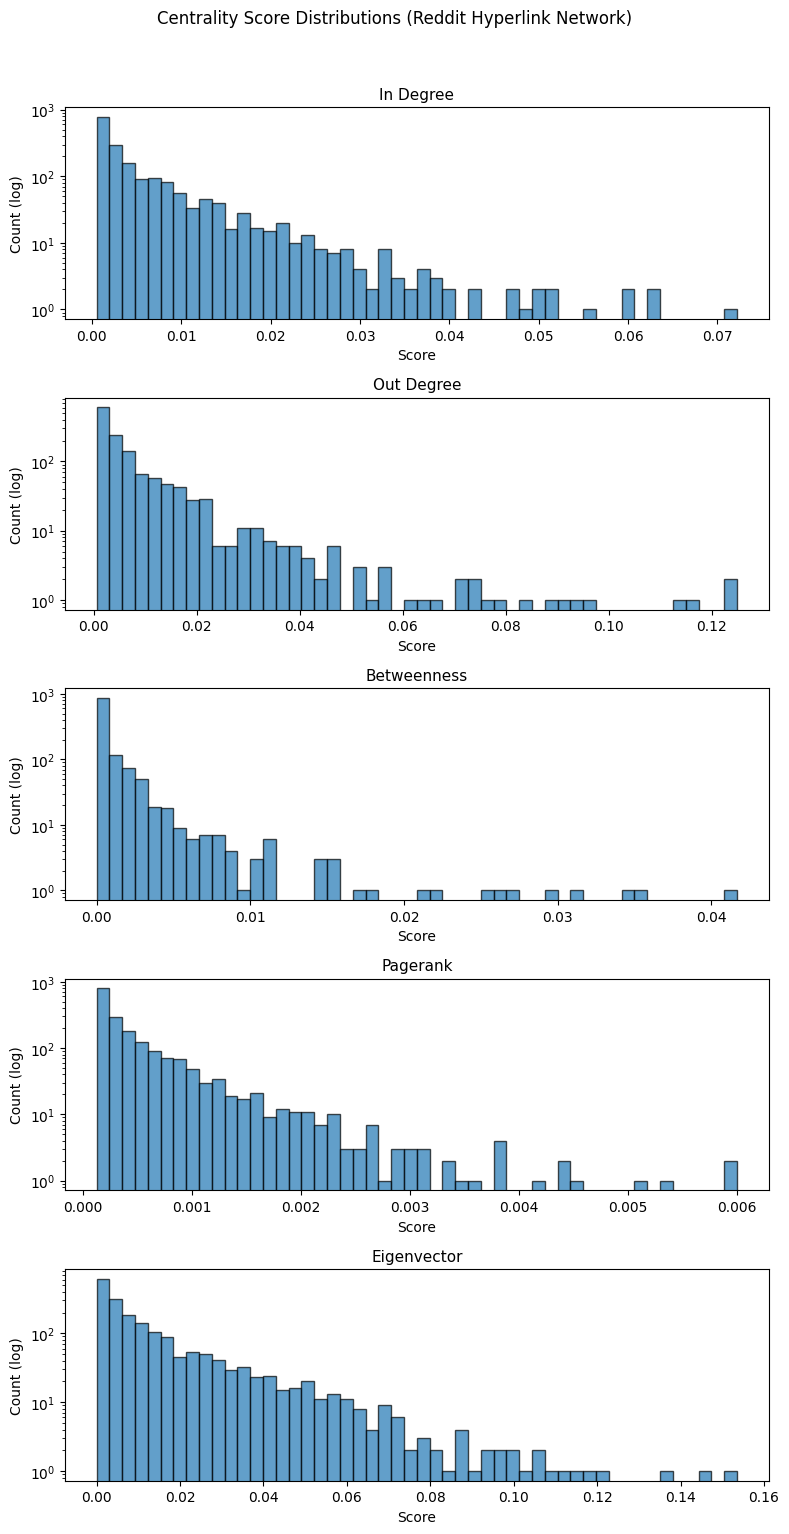

In [22]:
def plot_centrality_distributions(df):
    """Log-scale histogram of each centrality measure."""
    cols = ["in_degree", "out_degree", "betweenness", "pagerank", "eigenvector"]
    fig, axes = plt.subplots(5, 1, figsize=(8, 15))
    for ax, col in zip(axes, cols):
        vals = df[col]
        vals_pos = vals[vals > 0]
        ax.hist(vals_pos, bins=50, edgecolor="black", alpha=0.7, log=True)
        ax.set_title(col.replace("_", " ").title(), fontsize=11)
        ax.set_xlabel("Score")
        ax.set_ylabel("Count (log)")
    plt.suptitle("Centrality Score Distributions (Reddit Hyperlink Network)", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "centrality_distributions.png"), dpi=150)
    plt.show()

plot_centrality_distributions(df)

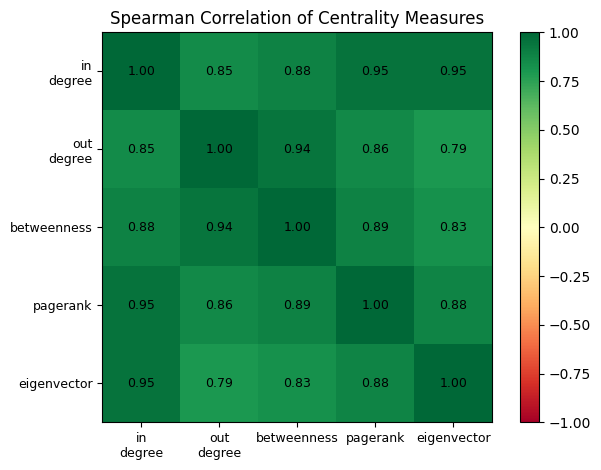

In [15]:
def plot_correlation_heatmap(corr):
    fig, ax = plt.subplots()
    im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
    labels = [c.replace("_", "\n") for c in corr.columns]
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im)
    plt.title("Spearman Correlation of Centrality Measures")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "centrality_correlation.png"), dpi=150)
    plt.show()

plot_correlation_heatmap(corr)

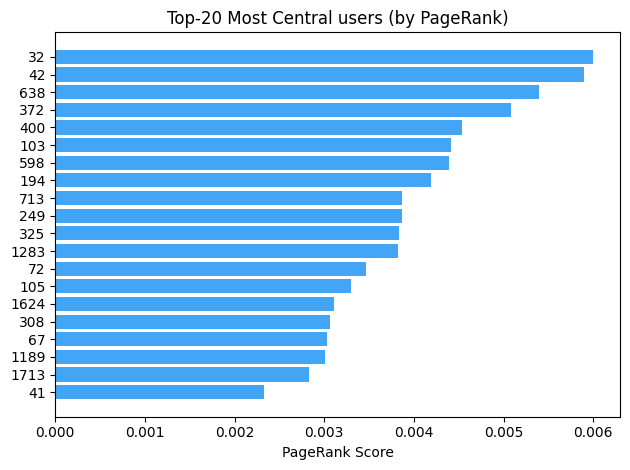

In [14]:
def plot_top_k_bar(consensus, k=20):
    """Horizontal bar chart of top-k users by PageRank."""
    top = consensus.nlargest(k, "pagerank").sort_values("pagerank")
    fig, ax = plt.subplots()
    ax.barh(top["users"].astype(str), top["pagerank"], color="#42A5F5")
    ax.set_xlabel("PageRank Score")
    ax.set_title(f"Top-{k} Most Central users (by PageRank)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "top_users_pagerank.png"), dpi=150)
    plt.show()

plot_top_k_bar(consensus, k=20)

In [25]:
def export_for_diffusion(G, consensus, k=20):
    # Top-k central seeds (consensus ranking)
    seeds_top = consensus["users"].tolist()[:k]

    # Random baseline seed set of same size
    rng = np.random.default_rng(42)
    all_nodes = list(G.nodes())
    seeds_random = rng.choice(all_nodes, size=k, replace=False).tolist()

    seed_data = {"top_central": seeds_top, "random_baseline": seeds_random}
    with open(os.path.join(output_dir, "seed_nodes.json"), "w") as f:
        json.dump(seed_data, f, indent=2)

export_for_diffusion(G, consensus, k=20)